# Knowledge Mindmap

This notebook builds a **knowledge mindmap** with it's center on one Wikipedia article.

Given a center page A and a list of related or unrelated target pages [B, C, D, E], we:
1. Run BFS from A to each target (B,C,D,E) to find the shortest path
2. Record hop-distances: how many clicks does it take to get from A to each target?
3. Compare distances with some targests closer and some furthur
4. Visualise everything as a radial map with A in its' center

In [23]:
import sys
sys.path.insert(0, "..")

from src import WikiMindmap, WikiScraper

## Configuration

- Set `CENTER` & `TARGETS` to explore knowledge that I'm interested in exploring.  
- `MAX_PAGES` caps the BFS search where higher means slower but more thorough search.

In [ ]:
CENTER = "Georgetown University"

TARGETS = [
    "Bulldog",  
    "Washington, D.C.",                              
    "Data science",                        
    "Dishwasher",                  
    "Ancient Rome",                         
    "Dinosaur",                            
]

MAX_PAGES = 500
scraper = WikiScraper(delay=0.1)

## Build the mindmap

For each target (B,C,D,E), BFS explores from the center A outward until it finds the target or hits the page limit.

In [26]:
mm = WikiMindmap(
    center=CENTER,
    scraper=scraper,
    max_pages=MAX_PAGES,
    verbose=True,
)

mm.build(TARGETS)


── Searching: 'Georgetown University'  →  'Bulldog' ──
  [   1/500] Georgetown University
  [   2/500] Georgetown College
  [   3/500] Latin language
  [   4/500] Georgetown College (Georgetown University)
  [   5/500] Latin
  [   6/500] Private university
  [   7/500] Research university
  [   8/500] John Carroll (archbishop of Baltimore)
  [   9/500] Higher education accreditation
  [  10/500] Middle States Commission on Higher Education
  [  11/500] Catholic Church
  [  12/500] Jesuit
  [  13/500] Consortium of Universities of the Washington Metropolitan Area
  [  14/500] Consortium on Financing Higher Education
  [  15/500] Coalition of Urban and Metropolitan Universities
  [  16/500] Global University Leaders Forum
  [  17/500] Financial endowment
  [  18/500] University president
  [  19/500] Robert Groves
  [  20/500] Undergraduate education
  [  21/500] Postgraduate education
  [  22/500] Washington, D.C.
  [  23/500] School colors
  [  24/500] Athletic nickname
  [  25/500] G

## Distance summary table

In [ ]:
mm.summary()


Knowledge distance from: 'Georgetown University'
Target                                    Hops  Path
------------------------------------------------------------
Washington, D.C.                             1  Georgetown University → Washington, D.C.
Bulldog                                      2  Georgetown University → Georgetown Hoyas → Bulldog
Data science                                 2  Georgetown University → Master of Science in Foreign Service → Data science
Ancient Rome                                 2  Georgetown University → Latin language → Ancient Rome
John Carroll                                 –  (not found within 500 pages)
Dinosaur                                     –  (not found within 500 pages)



## Statistics Summary

In [ ]:
closest  = mm.closest()
farthest = mm.farthest()

if closest:
    print(f"Closest  target: '{closest.target}'  ({closest.hops} hops)")
    print(f"  Path: {' → '.join(closest.path)}")
if farthest:
    print(f"\nFarthest target: '{farthest.target}'  ({farthest.hops} hops)")
    print(f"  Path: {' → '.join(farthest.path)}")

print("\nAll distances:")
for target, hops in sorted(mm.distances().items(), key=lambda x: (x[1] is None, x[1])):
    bar = "█" * (hops or 0)
    print(f"  {target:<40} {str(hops):>4} hops  {bar}")

Closest  target: 'Washington, D.C.'  (1 hops)
  Path: Georgetown University → Washington, D.C.

Farthest target: 'Bulldog'  (2 hops)
  Path: Georgetown University → Georgetown Hoyas → Bulldog

All distances:
  Washington, D.C.                            1 hops  █
  Bulldog                                     2 hops  ██
  Data science                                2 hops  ██
  Ancient Rome                                2 hops  ██
  John Carroll                             None hops  
  Dinosaur                                 None hops  


## Visulize with mindmap

Saved to mindmap.png


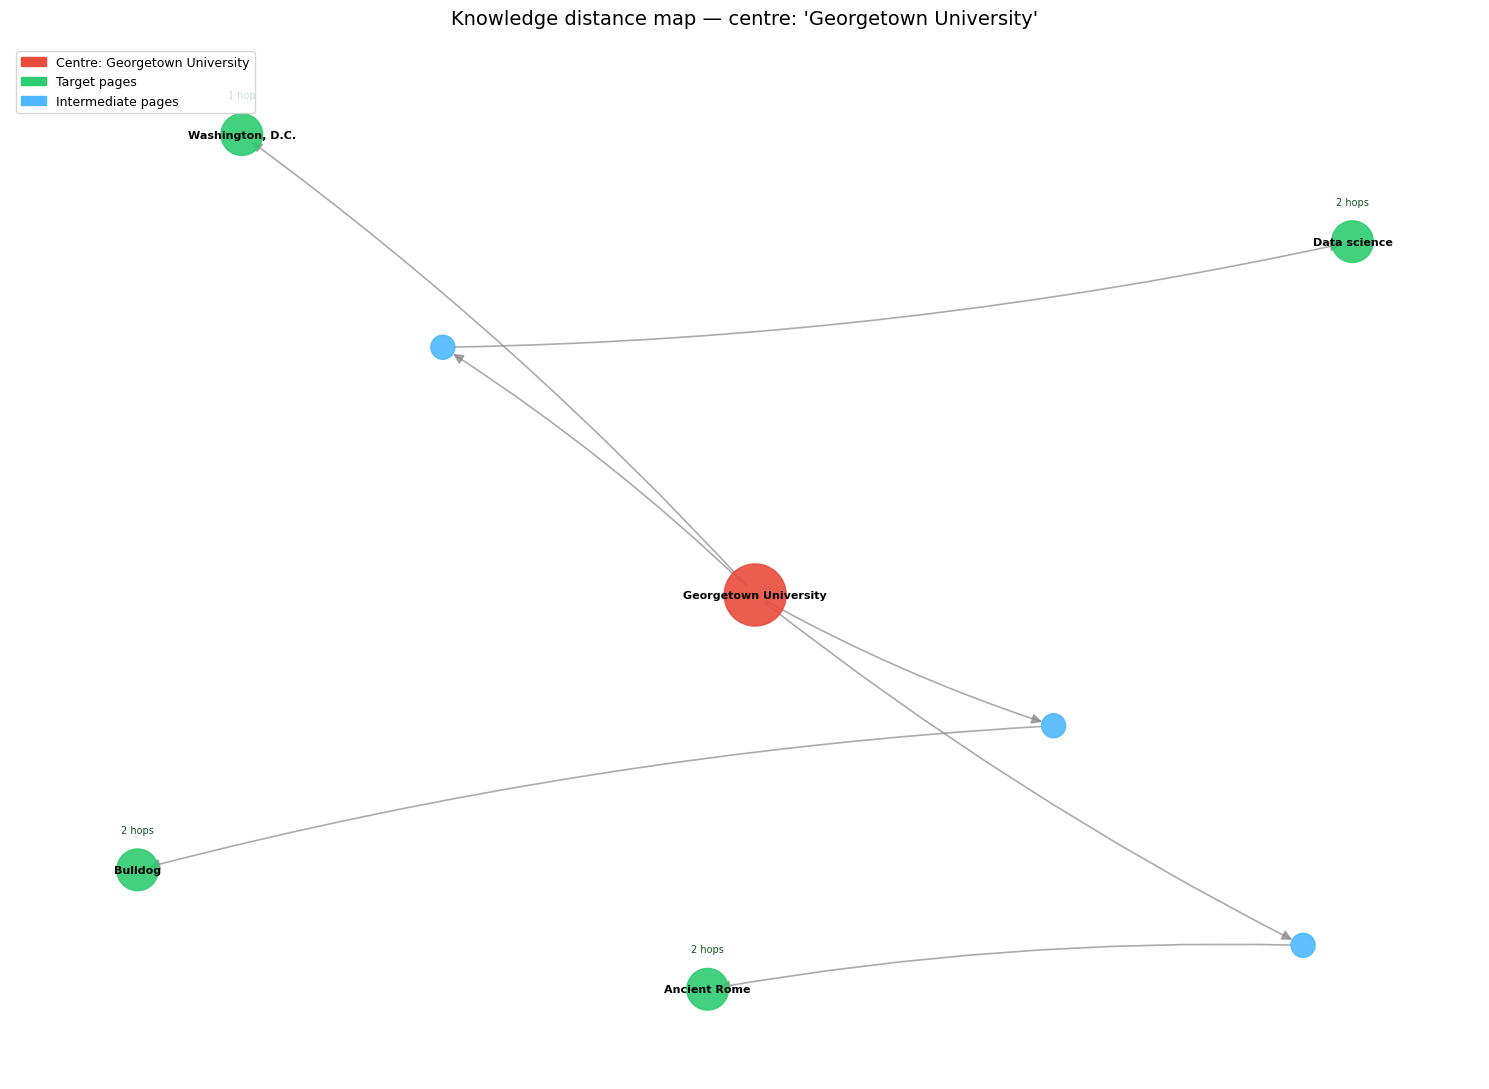

In [ ]:
mm.visualize(figsize=(15, 11), save_path="mindmap.png")

## Interpretation

The visualisation shows:
- **Red node** — the centre article (Georgetown University)
- **Green nodes** — target articles with their hop counts
- **Blue nodes** — intermediate pages on each shortest path
- **Arrows** — the direction links were followed

Targets with fewer hops are conceptually closer in Wikipedia's link structure.  
Targets many hops away require passing through more unrelated topics to reach.

For Georgetown University we expect:
- **Bulldog**, **John Carroll**, **Washington D.C.** → very close (1–2 hops), directly linked from the Georgetown page
- **Data science** → moderate distance (2–3 hops), connected via academic/research links
- **Ancient Rome**, **Dinosaur** → far (3+ hops), requiring many intermediate pages


Knowledge distance from: 'Washington, D.C.'
Target                                    Hops  Path
------------------------------------------------------------
Georgetown University                        1  Washington, D.C. → Georgetown University
White House                                  1  Washington, D.C. → White House
Ancient Rome                                 2  Washington, D.C. → National personification → Ancient Rome
Dinosaur                                     2  Washington, D.C. → National Mall → Dinosaur
Data science                                 –  (not found within 500 pages)

Saved to mindmap.png


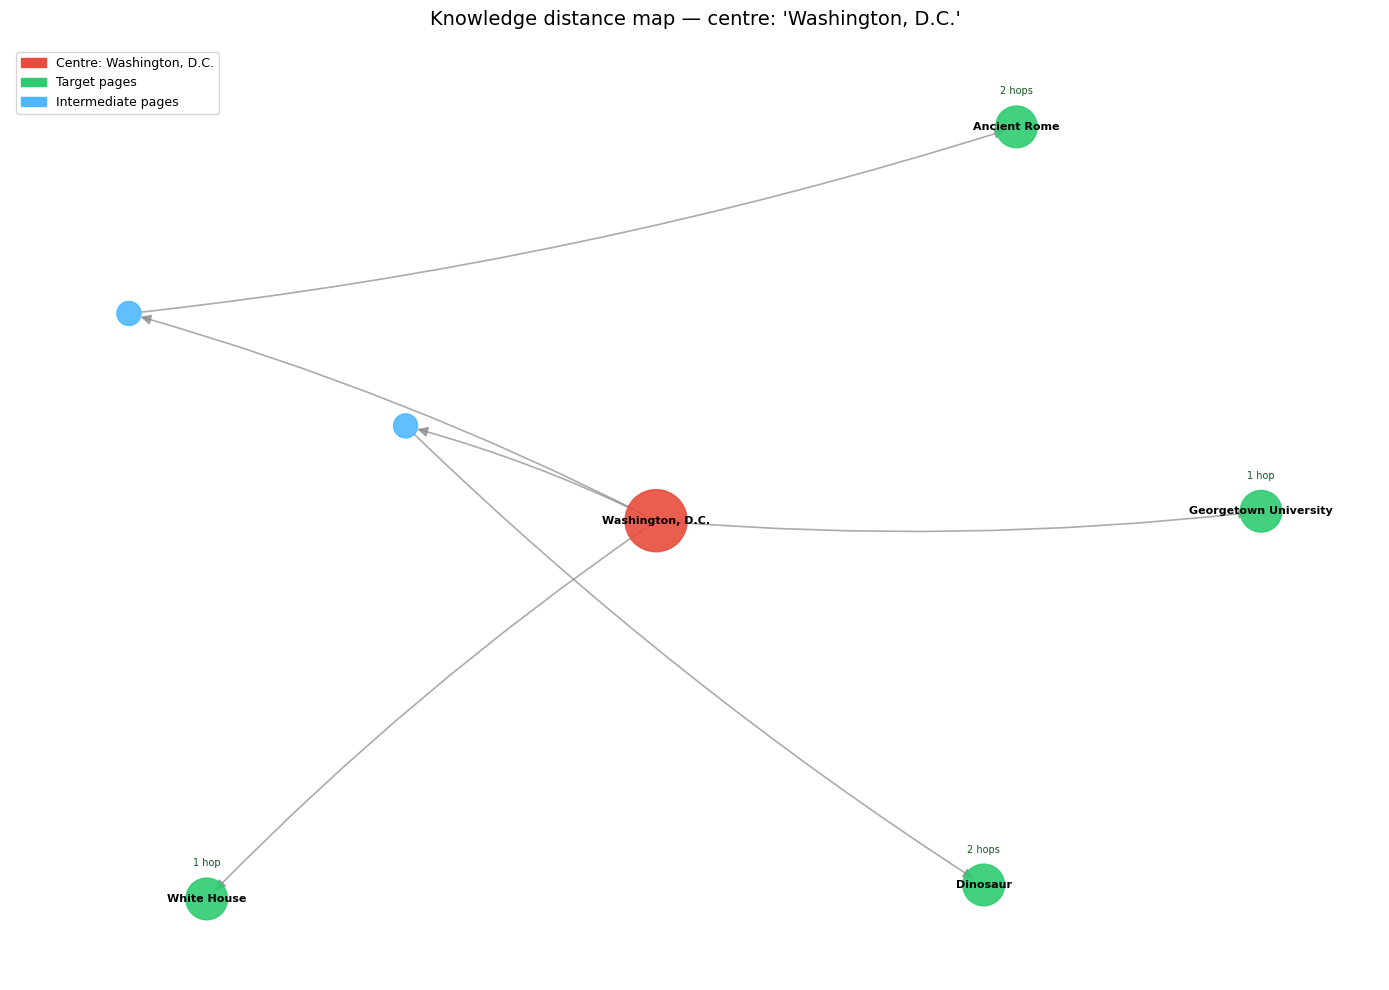

In [ ]:
# Try a different centre — Washington D.C. as the hub
mm2 = WikiMindmap(
    center="Washington, D.C.",
    scraper=scraper,
    max_pages=500,
    verbose=False,
)
mm2.build([
    "Georgetown University",    # local university — expected very close
    "White House",              # landmark in D.C. — expected close
    "Data science",             # moderate
    "Ancient Rome",             # far
    "Dinosaur",                 # very far
])
mm2.summary()
mm2.visualize(save_path="mindmap.png")